<a href="https://colab.research.google.com/github/Lety-more/es.coretti-/blob/main/genetica_volantino.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Biologia_Genetica(in).csv to Biologia_Genetica(in).csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from scipy import stats
import io

nome_file = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[nome_file]), delimiter=',')

print("=== ANTEPRIMA DEL DATASET DI GENETICA ===")
print(df.head())


=== ANTEPRIMA DEL DATASET DI GENETICA ===
  Generazione  Frequenza_Allele_Dominante  Presenza_Ambientale  \
0          F3                        0.90                    0   
1          F1                        0.43                    1   
2          F2                        0.77                    0   
3          F3                        0.67                    1   
4          F2                        0.75                    1   

  Tipo_Ereditarieta  Percentuale_Fenotipo_Dominante  
0        Incomplete                            59.8  
1        Mendeliana                            52.4  
2        Incomplete                            57.4  
3        Mendeliana                            68.1  
4        Poligenica                            43.9  


In [4]:
X = df[['Frequenza_Allele_Dominante']]
y = df['Percentuale_Fenotipo_Dominante']

model = LinearRegression()
model.fit(X, y)

print("\n=== RISULTATI REGRESSIONE SEMPLICE ===")
# float(...) impedisce l'errore di formattazione numpy riscontrato in precedenza
print(f"Intercetta (b0): {float(model.intercept_):.4f}")
print(f"Coefficiente Frequenza_Allele_Dominante (b1): {float(model.coef_[0]):.4f}")
print(f"R²: {float(model.score(X, y)):.4f}")


=== RISULTATI REGRESSIONE SEMPLICE ===
Intercetta (b0): 12.7796
Coefficiente Frequenza_Allele_Dominante (b1): 53.3748
R²: 0.2155


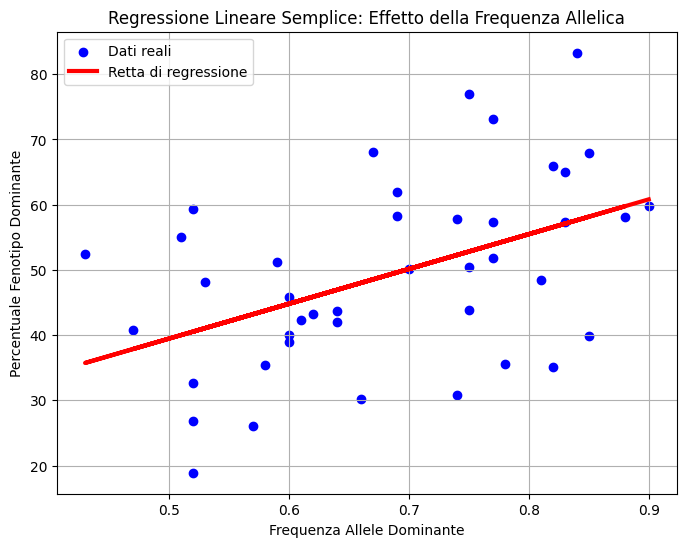

In [5]:
plt.figure(figsize=(8,6))
plt.scatter(df['Frequenza_Allele_Dominante'], df['Percentuale_Fenotipo_Dominante'], color='blue', label='Dati reali')
plt.plot(df['Frequenza_Allele_Dominante'], model.predict(X), color='red', linewidth=3, label='Retta di regressione')
plt.xlabel('Frequenza Allele Dominante')
plt.ylabel('Percentuale Fenotipo Dominante')
plt.title('Regressione Lineare Semplice: Effetto della Frequenza Allelica')
plt.legend()
plt.grid(True)

In [6]:
X_multi = df[['Frequenza_Allele_Dominante', 'Presenza_Ambientale']]
model_multi = LinearRegression()
model_multi.fit(X_multi, y)

print("\n=== RISULTATI REGRESSIONE MULTIPLA ===")
print("Coefficienti:")
for nome, coef in zip(X_multi.columns, model_multi.coef_):
    print(f"  {nome}: {coef:.4f}")
print(f"Intercetta: {float(model_multi.intercept_):.4f}")
print(f"R² Totale: {float(model_multi.score(X_multi, y)):.4f}")



=== RISULTATI REGRESSIONE MULTIPLA ===
Coefficienti:
  Frequenza_Allele_Dominante: 48.2655
  Presenza_Ambientale: 15.4536
Intercetta: 10.3875
R² Totale: 0.4883


In [7]:
gruppo0 = df[df['Presenza_Ambientale'] == 0]['Percentuale_Fenotipo_Dominante']
gruppo1 = df[df['Presenza_Ambientale'] == 1]['Percentuale_Fenotipo_Dominante']

t_stat, p_value = stats.ttest_ind(gruppo0, grupo1 if 'grupo1' in locals() else gruppo1)

print("\n=== RISULTATI T-TEST ===")
print(f"Media Condizioni Ideali: {gruppo0.mean():.3f}")
print(f"Media Stress Ambientale: {gruppo1.mean():.3f}")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.5f}")

if p_value < 0.05:
    print("→ Differenza statisticamente SIGNIFICATIVA!")
else:
    print("→ Differenza NON significativa")


=== RISULTATI T-TEST ===
Media Condizioni Ideali: 43.004
Media Stress Ambientale: 59.506
t-statistic: -4.273
p-value: 0.00012
→ Differenza statisticamente SIGNIFICATIVA!


/tmp/ipykernel_903/1171082231.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Presenza_Ambientale', y='Percentuale_Fenotipo_Dominante', data=df, palette=['lightblue', 'lightgreen'])


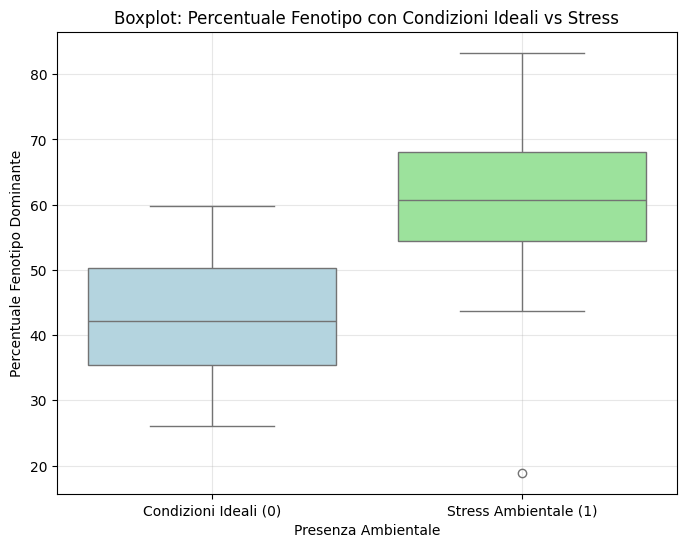

In [8]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Presenza_Ambientale', y='Percentuale_Fenotipo_Dominante', data=df, palette=['lightblue', 'lightgreen'])
plt.xticks([0, 1], ['Condizioni Ideali (0)', 'Stress Ambientale (1)'])
plt.title('Boxplot: Percentuale Fenotipo con Condizioni Ideali vs Stress')
plt.ylabel('Percentuale Fenotipo Dominante')
plt.xlabel('Presenza Ambientale')
plt.grid(True, alpha=0.3)